In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import os


import pyrootutils

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("TF_ENABLE_ONEDNN_OPTS", "0")
os.environ.setdefault("TF_XLA_FLAGS", "--tf_xla_auto_jit=0")
os.environ.setdefault("TF_GPU_ALLOCATOR", "cuda_malloc_async")
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 
import tensorflow as tf

tf.get_logger().setLevel('ERROR')

ROOT = pyrootutils.setup_root(
    search_from=Path.cwd(),
    indicator="pyproject.toml",
    pythonpath=True,
    dotenv=True,
)


2026-05-08 12:05:10.489764: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-08 12:05:10.528390: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-08 12:05:10.528544: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
from building.scaling import (
    ScalingRunConfig,
    load_full_arrays,
    run_experiments,
    summarize_results,
    plot_summary,
)

In [4]:
COLLECTION = "diff_genus"
N_SAMPLES = 20
EPOCHS = 50
PATIENCE = 7
BATCH_SIZE = 32
SEED = 42
THRESHOLD = 0.5
BUILD_MODEL = "mel_cnn"
INPUT_REPR = "mel"
MODELS_DIR = ROOT / "models" / BUILD_MODEL
RESULTS_FILE = MODELS_DIR / "results.jsonl"

In [5]:
config = ScalingRunConfig(
    collection=COLLECTION,
    build_model=BUILD_MODEL,
    epochs=EPOCHS,
    patience=PATIENCE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    threshold=THRESHOLD,
    models_dir=MODELS_DIR,
    results_file=RESULTS_FILE,
    input_repr=INPUT_REPR,
)

catalog = load_full_arrays(
    collection=COLLECTION,
    batch_size=BATCH_SIZE,
    seed=SEED,
    input_repr=INPUT_REPR,
)

print(f"Loaded {len(catalog.class_names)} classes:")
print(catalog.class_names)

Found 2450 files belonging to 1 classes.
Found 525 files belonging to 1 classes.
Found 525 files belonging to 1 classes.
Found 2450 files belonging to 1 classes.
Found 525 files belonging to 1 classes.
Found 525 files belonging to 1 classes.
Found 2450 files belonging to 1 classes.
Found 525 files belonging to 1 classes.
Found 525 files belonging to 1 classes.
Found 2450 files belonging to 1 classes.
Found 525 files belonging to 1 classes.
Found 525 files belonging to 1 classes.
Found 2450 files belonging to 1 classes.
Found 525 files belonging to 1 classes.
Found 525 files belonging to 1 classes.
Found 2450 files belonging to 1 classes.
Found 525 files belonging to 1 classes.
Found 525 files belonging to 1 classes.
Found 2450 files belonging to 1 classes.
Found 525 files belonging to 1 classes.
Found 525 files belonging to 1 classes.
Found 2450 files belonging to 1 classes.
Found 525 files belonging to 1 classes.
Found 525 files belonging to 1 classes.
Found 2450 files belonging to 1 

In [6]:

baseline_rows = run_experiments(
    catalog,
    config,
    run_baseline=True,
    run_scaling=False,
)
print(f"New baseline runs: {len(baseline_rows)}")
if baseline_rows:
    print("Last baseline row:")
    print(baseline_rows[-1])

New baseline runs: 0


In [7]:
from building.scaling import print_baselines
print_baselines(catalog, RESULTS_FILE)

Target Class            | Precision |    Recall | Epochs | Timestamp
--------------------------------------------------------------------
'Carduelis_carduelis'   |    0.8871 ±    0.0007 |    0.8905 ±    0.0010 |    0.8888 ±    0.0001 |     11 
'Carpodacus_erythrinus' |    0.9480 ±    0.0076 |    0.9533 ±    0.0086 |    0.9506 ±    0.0004 |     14 
'Chloris_chloris'       |    0.9490 ±    0.0155 |    0.9467 ±    0.0152 |    0.9476 ±    0.0001 |     14 
'Fringilla_coelebs'     |    0.9409 ±    0.0084 |    0.9371 ±    0.0095 |    0.9389 ±    0.0006 |     12 
'Linaria_cannabina'     |    0.8931 ±    0.0330 |    0.8981 ±    0.0390 |    0.8941 ±    0.0028 |     12 
'Loxia_pytyopsittacus'  |    0.8876 ±    0.0089 |    0.8857 ±    0.0114 |    0.8865 ±    0.0013 |     14 
'Pyrrhula_pyrrhula'     |    0.9073 ±    0.0016 |    0.9133 ±    0.0010 |    0.9103 ±    0.0003 |     12 
'Serinus_serinus'       |    0.9495 ±    0.0133 |    0.9438 ±    0.0067 |    0.9465 ±    0.0033 |     12 
'Spinus_spinus

In [ ]:
scaling_rows = run_experiments(
    catalog,
    config=config,
    n_samples=N_SAMPLES,
    k_values=range(2, 6),
    run_baseline=False,
    run_scaling=True,
)
print(f"New scaling runs: {len(scaling_rows)}")
if scaling_rows:
    print("Last scaling row:")
    print(scaling_rows[-1])

In [7]:
baseline_metrics, summary_df = summarize_results(RESULTS_FILE)
print(f"Baseline recall: {baseline_metrics.recall:.4f}")
print(f"Baseline precision: {baseline_metrics.precision:.4f}")
summary_df

Baseline recall: 0.9208
Baseline precision: 0.9199


,k,recall_mean,recall_std,precision_mean,precision_std,f1_mean,f1_std,top1_acc_mean,top1_acc_std,loss_mean,loss_std
0,2,0.828603,0.143912,0.860788,0.100197,0.838735,0.135316,0.853968,0.102121,0.224333,0.083662
1,3,0.800238,0.127715,0.857559,0.089029,0.820937,0.121979,0.840238,0.091735,0.189391,0.062838
2,4,0.760095,0.107350,0.844492,0.082723,0.791938,0.105199,0.819581,0.082303,0.174341,0.049013
3,5,0.694698,0.098474,0.805955,0.068197,0.730955,0.097072,0.774270,0.073527,0.173679,0.037095
4,6,0.707932,0.089513,0.824233,0.063233,0.743871,0.089871,0.791129,0.064916,0.147161,0.029461
5,7,0.700782,0.084743,0.833742,0.057260,0.738872,0.086199,0.795442,0.063707,0.130372,0.025786


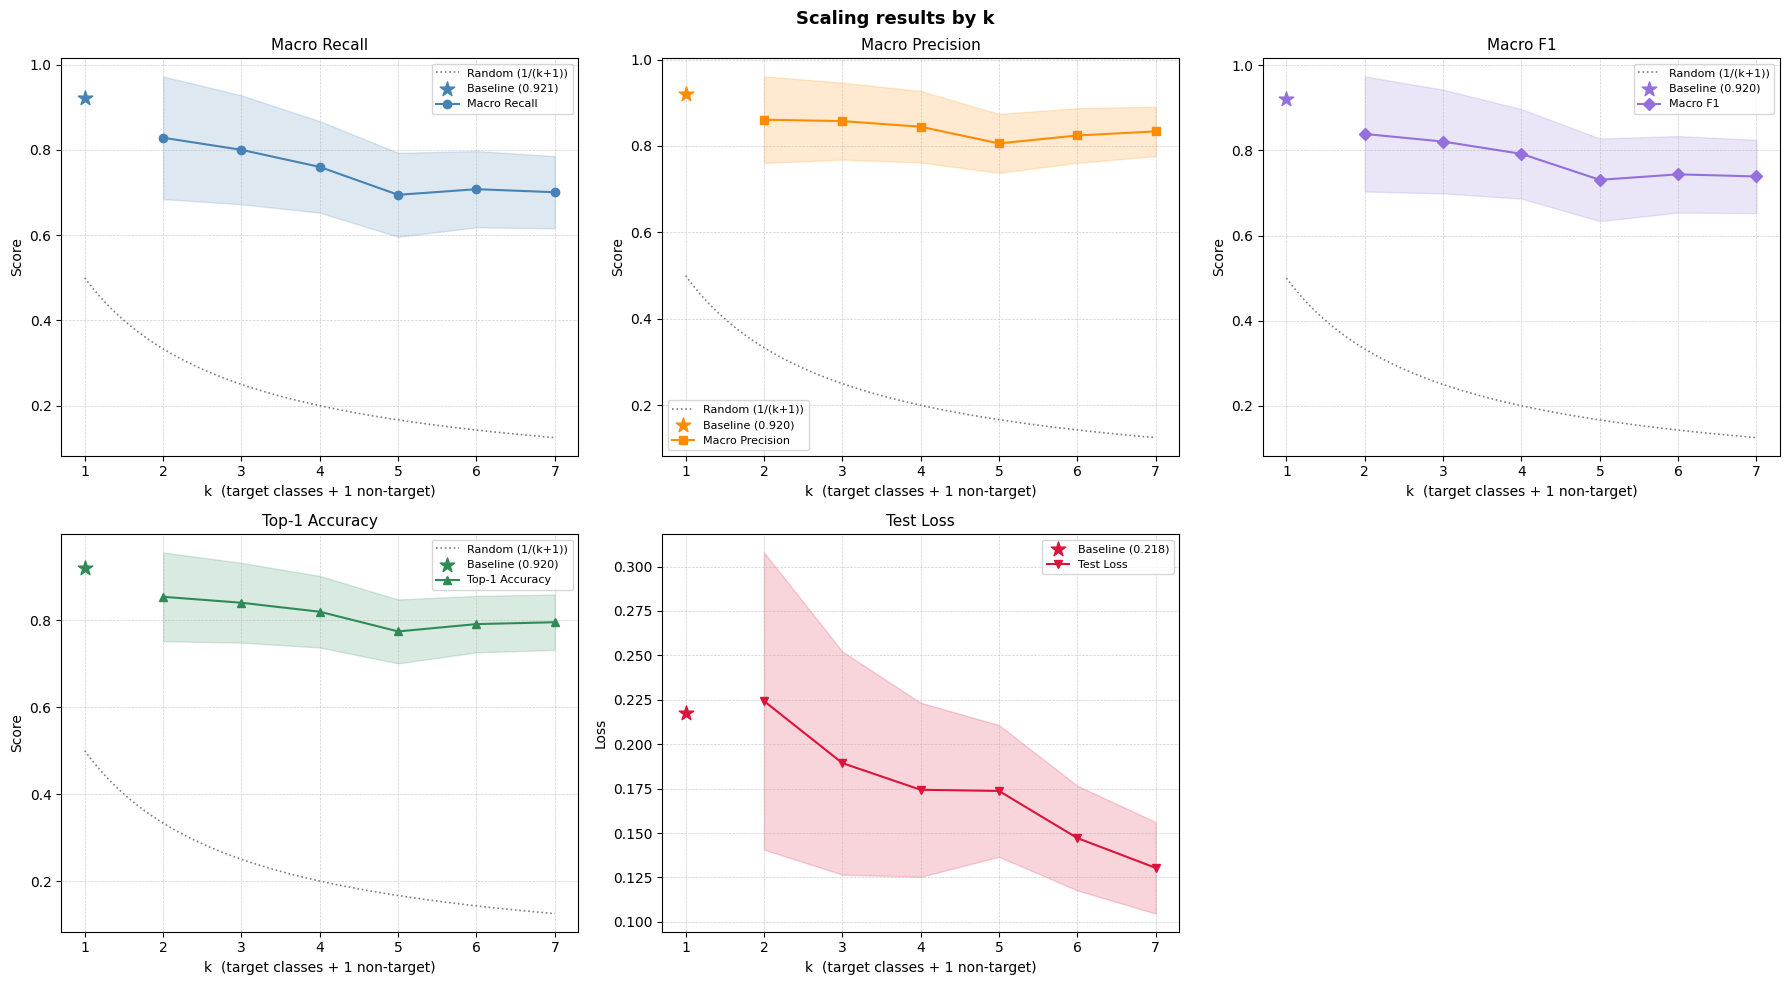

In [8]:
plot_summary(summary_df, baseline=baseline_metrics)